### [ 주제 : 소음 강도별 성능 비교 실험 ]
- **[0] 설정** : 모듈, 상수, 레벨별 데이터 경로
- **[1] 헬퍼** : 전처리·모델·평가 함수/클래스
- **[2] run_pipeline** : wav 폴더 하나 → AUC 하나 (핵심)
- **[3] 실행** : 레벨마다 run_pipeline 호출 → AUC 수집
- **[4] 비교 그래프 + 해석**

> 데이터: 6dB / 0dB / -6dB 3레벨 (`data/slider`=-6dB, `data/slider_6dB`, `data/slider_0dB`).
> 소음만 바꾸고 나머지(기계 id_00, 하이퍼파라미터)는 고정 — 공정한 비교(통제 변인).

**📍 흐름 지도**

```
DATA_DIRS = {'-6dB': '../data/slider', ...}   # 지금은 -6dB만. 6dB/0dB 받으면 추가
     │  for level in DATA_DIRS:
     ▼
 run_pipeline(그 레벨 폴더)
     │   wav → mel → 8:2 분리 → 정규화 → AE 학습 30에포크 → 복원오차 → AUC
     ▼
 auc_results = {'-6dB': 0.xx, ...}
     ▼
 막대그래프 (소음이 셀수록 AUC가 얼마나 떨어지나)
```

In [ ]:
## [0] 모듈 + 설정
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import numpy as np
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score

N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 512
TRAIN_RATIO = 0.8
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

## 소음 레벨별 wav 폴더 (data/slider = -6dB)
DATA_DIRS = {'6dB':  '../data/slider_6dB',
             '0dB':  '../data/slider_0dB',
             '-6dB': '../data/slider'}

In [3]:
## [1] 헬퍼 : 02/03/04에서 쓴 것들 재사용 (대부분 복사, 새건 load_mel 하나)

def wav_to_mel(file_path):                                   # 02
    y, sr = librosa.load(file_path, sr=None)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                         n_fft=N_FFT, hop_length=HOP_LENGTH)
    return librosa.power_to_db(mel)

def load_mel(data_dir, label):                               # 02의 변환 루프 (id_00만)
    folder = f'{data_dir}/id_00/{label}'
    filelist = os.listdir(folder)
    filelist.sort()
    mel_list = []
    for i in range(len(filelist)):
        mel_list.append(wav_to_mel(f'{folder}/{filelist[i]}'))
    return np.array(mel_list)

class MelDataset(Dataset):                                   # 03
    def __init__(self, dataNP):
        super().__init__()
        self.data = dataNP.reshape(len(dataNP), -1)
        self.rows = len(dataNP)
    def __len__(self):
        return self.rows
    def __getitem__(self, index):
        return torch.FloatTensor(self.data[index])

class AutoEncoder(nn.Module):                                # 03
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(20032,512), nn.ReLU(),
                                     nn.Linear(512,64), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(64,512), nn.ReLU(),
                                     nn.Linear(512,20032), nn.Sigmoid())
    def forward(self, x):
        return self.decoder(self.encoder(x))

def recon_errors(model, dataNP):                             # 04
    model.eval()
    with torch.no_grad():
        x = torch.FloatTensor(dataNP.reshape(len(dataNP), -1)).to(DEVICE)
        out = model(x)
        err = ((x - out) ** 2).mean(dim=1)
    return err.cpu().numpy()

In [4]:
## [2] run_pipeline : 한 레벨 폴더 → AUC (이 노트북의 핵심)
## -> 매개변수 : data_dir - 그 레벨의 wav 폴더 (예: '../data/slider_-6dB')
## -> 결과     : AUC 값 하나
def run_pipeline(data_dir):
    normalNP = load_mel(data_dir, 'normal')
    abnormalNP = load_mel(data_dir, 'abnormal')
    
    np.random.seed(42)
    idx = np.random.permutation(len(normalNP))
    TRAIN_NUM = int(len(normalNP) * TRAIN_RATIO)
    trainNP       = normalNP[idx[:TRAIN_NUM]]
    test_normalNP = normalNP[idx[TRAIN_NUM:]]

    MIN, MAX = trainNP.min(), trainNP.max()
    trainNP     = (trainNP - MIN) / (MAX - MIN)
    test_normalNP     = (test_normalNP - MIN) / (MAX - MIN)
    test_abnormalNP     = (abnormalNP - MIN) / (MAX - MIN)

    trainDL = DataLoader(MelDataset(trainNP), batch_size=BATCH_SIZE, shuffle=True)
    model = AutoEncoder().to(DEVICE)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(EPOCHS):
        model.train()
        for feature in trainDL:
            feature = feature.to(DEVICE)
            out = model(feature)
            optimizer.zero_grad()
            loss = loss_fn(out, feature)
            loss.backward()
            optimizer.step()
    
    err_normal   = recon_errors(model, test_normalNP)
    err_abnormal = recon_errors(model, test_abnormalNP)
    y_true  = np.array([0]*len(err_normal) + [1]*len(err_abnormal))
    y_score = np.concatenate([err_normal, err_abnormal])
    return roc_auc_score(y_true, y_score)

In [5]:
## [3] 레벨별 실행 (레벨당 ≈ 2~3분)
auc_results = {}
for level in DATA_DIRS:
    print(f'{level} 실행 중 ...')
    auc_results[level] = run_pipeline(DATA_DIRS[level])
    print(f'{level} AUC : {auc_results[level]:.4f}')


 6dB 실행 중 ...
 6dB AUC : 0.9980
0dB 실행 중 ...
0dB AUC : 0.9884
-6dB 실행 중 ...
-6dB AUC : 0.9608


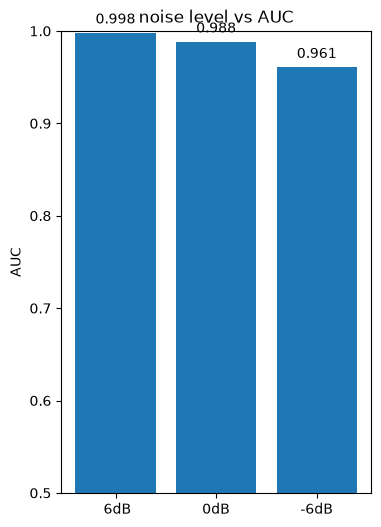

In [7]:
## [4] 비교 막대그래프

levels = list(DATA_DIRS.keys())
aucs = []
for lv in levels:
    aucs.append(auc_results[lv])

plt.figure(figsize=(4, 6))
plt.bar(levels, aucs)
plt.ylim(0.5, 1.0)             # 0.5 = 동전던지기 바닥
plt.ylabel('AUC')
plt.title('noise level vs AUC')
for i in range(len(levels)):
    plt.text(i, aucs[i] + 0.01, f'{aucs[i]:.3f}', ha='center')
plt.show()

## 결과 해석

| 소음 레벨 | AUC |
|-----------|-----|
| 6dB (가장 조용) | 0.998 |
| 0dB (중간) | 0.988 |
| -6dB (가장 시끄러움) | 0.961 |

- 소음이 셀수록 AUC가 단조 감소하지만 **완만함**(0.998 → 0.961, 폭 0.037) — 급락이 아니다.
- 가장 시끄러운 -6dB에서도 0.96을 유지 → id_00 슬라이더는 소음에 강하다 (우아한 성능 저하).
- 해석: 이상음의 특징이 배경소음("노이즈 안개")을 뚫고 나올 만큼 뚜렷해, 전 소음 구간에서 실용 가능.

## 다음 단계

- 06 : 실험 결과를 아진산업 프레스 도입 시나리오로 문서화 (+ 판정 로그 DB, Streamlit 데모)